# 04. Applying Gaussian Processes To HUXt Runs

**What this notebook is.** Notebook 02 built a HUXt input for one event. A single HUXt run is fast (seconds to a minute), but the science questions here - *how does CME arrival time depend on launch parameters?*, *which parameters matter most?*, *where should the next run go?* - need **thousands** of evaluations across the 5-D parameter space. While HUXt is designed for speed, a more expensive model like EUHFORIA would be prohibitive at that scale.

**The surrogate idea.** Run HUXt at a few hundred carefully chosen parameter vectors, then fit a cheap **Gaussian-process (GP) surrogate** that emulates HUXt: given any parameter vector it returns, instantly, a predicted arrival time *and* an uncertainty, plus a hit/miss probability. `scripts/gp_huxt_surrogate.py` is that pipeline. (GP fundamentals are in notebook 01.)

**What we do here.** We take the pipeline apart **one operation at a time**. Instead of only reading the finished files under `runs/gp_surrogate/<event>/`, each task **reimplements the underlying step inline** so you can see exactly what the script computes, and names the script function it mirrors.

The tasks follow that order:

1. **`design`** - build parameter bounds and a Latin-hypercube sample table.
2. **`run` / `detect_arrival`** - replay HUXt once for the seed and detect the arrival (the only task that launches a live simulation).
3. **`fit`** - train the hit classifier and the arrival regressor from scratch.
4. **`analyze`** - five independent sub-tasks: pairwise slices, local sensitivity, permutation importance, posterior arrival time, and next-run selection.
5. **Compare** - check the inline reconstructions against the committed CLI figures.

Each task re-loads what it needs, so they can be run independently once the setup cells have executed.

In [22]:
# --- Google Colab bootstrap (no-op locally) ---
import sys, os

if "google.colab" in sys.modules:
    REPO_URL = os.environ.get("CONECAST_REPO", "https://github.com/georgemilosh/conecast")
    REPO_DIR = "/content/conecast"
    if not os.path.isdir(REPO_DIR):
        os.system(f"git clone --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)
    # Decide what to do from whether the deps actually import (not from the clone existing),
    # so a failed/partial install self-heals on a re-run.
    try:
        import sunpy, huxt, wsaplus  # noqa: F401
        print("Colab bootstrap complete; cwd =", os.getcwd())
    except ModuleNotFoundError:
        print("Installing sunpy + WSA+ + HUXt (one-time, ~2 min)...")
        # Install in two steps so sunpy/wsaplus land even if the git build of HUXt is slow.
        os.system("pip install -q sunpy wsaplus")
        os.system("pip install -q "
                  "'huxt @ git+https://github.com/University-of-Reading-Space-Science/HUXt'")
        # Those installs pull a newer NumPy/SciPy; restart so it loads cleanly.
        print("Done - restarting the runtime. When it reconnects, RUN THIS CELL AGAIN "
              "(or Runtime > Run all).")
        os.kill(os.getpid(), 9)
    # The WSA+ checkpoint (~317 MB) is fetched from Zenodo on demand by notebook 02.
else:
    print("Not in Colab - using the local checkout.")

Not in Colab - using the local checkout.


In [23]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
if (cwd / "scripts").exists():
    BASE_DIR = cwd
elif (cwd.parent / "scripts").exists():
    BASE_DIR = cwd.parent
else:
    # Fallback: assume the notebook is run from inside the repo.
    BASE_DIR = cwd

SCRIPT_DIR = BASE_DIR / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

print("BASE_DIR =", BASE_DIR)

BASE_DIR = /Users/u0167590/github/conecast


## Workflow Order

`gp_huxt_surrogate.py` is organized around subcommands:

| step | script function | input | output |
| --- | --- | --- | --- |
| `design` | `make_design()` | `data_dir/sw/<event>/event_config.yaml` | `design.csv`, `design_meta.yaml` |
| `run` | `run_design()` / `detect_arrival()` | `design.csv`, HUXt boundary/config | `results.csv` |
| `visualize-threshold` | `visualize_threshold_cases()` | completed rows in `results.csv` | `figures/threshold_diagnostics/` |
| `fit` | `train_models()` | completed `results.csv` | `gp_hit.joblib`, `gp_arrival.joblib` |
| `analyze` | `analyze_event()` | trained GP bundles | `summary.yaml`, figures, `next_runs.csv` |

> **Two surrogates, not one.** A CME that misses Earth has no arrival time, so the script trains a **classifier** for *whether* it hits and a separate **regressor** for *when* - the latter only on the runs that actually hit. Keep that split in mind throughout.

## Setup

Import the shared libraries and the module-level constants that `gp_huxt_surrogate.py` uses.

> **What Tasks 3-5 need.** They train/analyze the GP on a **completed HUXt batch** (`results.csv` under `runs/gp_surrogate/<event>/`). If it does not exist, Task 3 **generates one inline** (reusing the script's design + run, ~200 HUXt samples, tens of minutes) so the notebook is self-contained - it only needs the event's boundary from notebook 02 (or `generate_huxt_input.py`). Lower `N_BATCH` in that cell for a quick look. The batch is saved, so re-runs are instant.

In [24]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display, Image
from joblib import load

GP_ROOT = BASE_DIR / "runs" / "gp_surrogate"
DATA_ROOT = BASE_DIR / "data_dir" / "sw"
PARAM_NAMES = ["inject_hour", "longitude", "latitude", "width", "v"]

# Constants mirrored from gp_huxt_surrogate.py (PRIOR_LOW/HIGH, DEFAULT_ABS_SPAN, DEFAULT_OBS_SIGMA).
PRIOR_LOW = np.array([0.0, -90.0, -50.0, 0.0, 100.0], dtype=float)
PRIOR_HIGH = np.array([10.0, 90.0, 50.0, 180.0, 2000.0], dtype=float)
DEFAULT_ABS_SPAN = np.array([1.0, 30.0, 20.0, 40.0, np.nan], dtype=float)
DEFAULT_OBS_SIGMA = np.array([0.5, 10.0, 10.0, 15.0, np.nan], dtype=float)
# design subcommand defaults (argparse): inject_hour, longitude, latitude, width spans + speed fraction.
DEFAULT_SPAN = dict(inject_hour=1.0, longitude=30.0, latitude=20.0, width=40.0, speed_fraction=0.25)

# Pick an event. Tasks 3-5 need GP outputs under runs/gp_surrogate/<event>/,
# produced by: python scripts/gp_huxt_surrogate.py --event <event> design/run/fit
event = "2017-09-06"
outdir = GP_ROOT / event

print("Prepared GP event directories:")
if GP_ROOT.exists():
    for path in sorted(GP_ROOT.iterdir()):
        if path.is_dir() and (path / "design.csv").exists():
            print(" ", path.name)
else:
    print("  (none yet - runs/gp_surrogate/ does not exist)")
print("\nUsing event:", event)
print("Output dir exists:", outdir.exists(), "(needs gp_huxt_surrogate.py design/run/fit)")

Prepared GP event directories:
  2017-09-06

Using event: 2017-09-06
Output dir exists: True (needs gp_huxt_surrogate.py design/run/fit)


## Task 1: The `design` Step - bounds and Latin-hypercube sampling

*Mirrors `make_design()`, `design_span()`, `default_bounds()`, and `latin_hypercube()`.*

Before training a surrogate you must decide **where** to evaluate HUXt. That is a design-of-experiments problem: with only a few hundred runs to spend across 5 dimensions, you want them spread out, not clustered. The `design` step does three things:

1. **Bounds** (`default_bounds`/`design_span`): build a box around the seed `initial_theta` - a span on each parameter (the speed span is a *fraction* of the seed speed; the others absolute) clipped to the global physical priors `PRIOR_LOW`/`PRIOR_HIGH`.
2. **Latin-hypercube sample** (`latin_hypercube`): draw points so each parameter's range is evenly covered. Unlike uniform random sampling, a Latin hypercube guarantees no gaps or clumps in any single dimension - much better coverage for the same number of runs.
3. **Seed row**: prepend the seed vector as row 0, so the best-guess CME is always evaluated.

We reconstruct each step and check the result against the saved `design.csv`.

> **What to look for:** the per-parameter histograms should be roughly flat across each bound (even coverage), with the black seed line inside the range, and the reconstructed table should match the saved design exactly.

In [25]:
# 1a. Load the seed parameter vector from the event config.
config_path = DATA_ROOT / event / "event_config.yaml"
with config_path.open() as stream:
    config = yaml.safe_load(stream)
theta0 = np.array([float(x) for x in config["initial_theta"]], dtype=float)

print("seed theta0:")
display(pd.Series(theta0, index=PARAM_NAMES))

seed theta0:


inject_hour       3.716667
longitude        23.000000
latitude        -15.000000
width            88.000000
v              1238.000000
dtype: float64

In [26]:
# 1b. Build the span and the bounds box (design_span + default_bounds).
# The speed span is a fraction of the seed speed; the others are absolute.
span = np.array([
    DEFAULT_SPAN["inject_hour"],
    DEFAULT_SPAN["longitude"],
    DEFAULT_SPAN["latitude"],
    DEFAULT_SPAN["width"],
    DEFAULT_SPAN["speed_fraction"] * theta0[4],
], dtype=float)

# Clip the box to the global priors so it never leaves the physical range.
low = np.maximum(PRIOR_LOW, theta0 - span)
high = np.minimum(PRIOR_HIGH, theta0 + span)

bounds = pd.DataFrame({"low": low, "theta0": theta0, "high": high}, index=PARAM_NAMES)
print("Bounds box around the seed:")
display(bounds)

Bounds box around the seed:


,low,theta0,high
inject_hour,2.716667,3.716667,4.716667
longitude,-7.000000,23.000000,53.000000
latitude,-35.000000,-15.000000,5.000000
width,48.000000,88.000000,128.000000
v,928.500000,1238.000000,1547.500000


In [27]:
# 1c. Draw a Latin-hypercube sample in the unit cube, then map it into the box.
# This mirrors latin_hypercube(): prefer scipy's qmc, fall back to a numpy permutation design.
def latin_hypercube(n, ndim, seed):
    try:
        from scipy.stats import qmc
        sampler = qmc.LatinHypercube(d=ndim, seed=seed)
        return sampler.random(n)
    except Exception:
        rng = np.random.default_rng(seed)
        sample = np.empty((n, ndim), dtype=float)
        for dim in range(ndim):
            sample[:, dim] = (rng.permutation(n) + rng.random(n)) / n
        return sample

n = 300       # design --n default
seed = 42     # design --seed default
n_random = max(0, n - 1)
unit = latin_hypercube(n_random, len(PARAM_NAMES), seed)
theta = low + unit * (high - low)
theta = np.vstack([theta0, theta])   # row 0 is the seed

recon = pd.DataFrame(theta, columns=PARAM_NAMES)
print("reconstructed design shape:", recon.shape)
display(recon.head())

reconstructed design shape: (300, 5)


,inject_hour,longitude,latitude,width,v
0,3.716667,23.000000,-15.000000,88.000000,1238.000000
1,3.634567,40.671128,-28.693458,89.284985,1027.676268
2,4.670007,45.422514,3.557048,117.798498,995.885321
3,3.202481,50.205331,-14.885467,112.529027,1513.458283
4,4.360632,36.433863,-12.934959,72.393945,1490.295986


saved design shape: (200, 8)
saved metadata bounds match reconstruction: True
seed row (row 0) matches: True


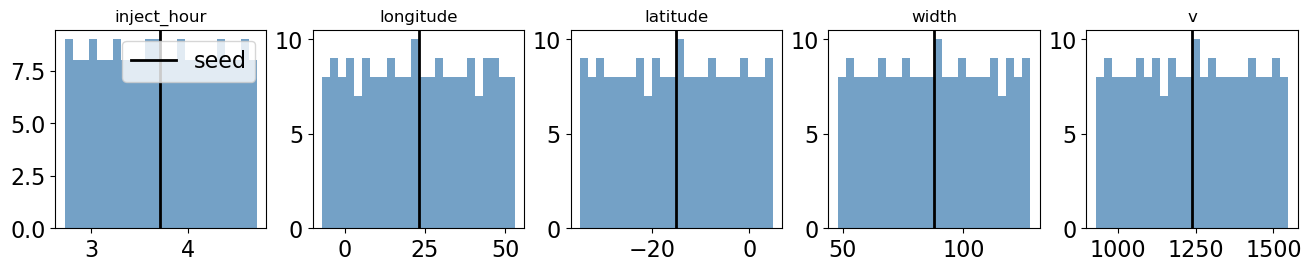

In [28]:
# 1d. Compare with the committed design.csv if present; else use the reconstruction.
design_file = outdir / "design.csv"
if design_file.exists():
    design = pd.read_csv(design_file)
    with (outdir / "design_meta.yaml").open() as stream:
        design_meta = yaml.safe_load(stream)
    print("saved design shape:", design.shape)
    print("saved metadata bounds match reconstruction:",
          np.allclose(design_meta["bounds_low"], low) and np.allclose(design_meta["bounds_high"], high))
    print("seed row (row 0) matches:", np.allclose(design.loc[0, PARAM_NAMES].to_numpy(float), theta0))
else:
    print(f"No saved design.csv yet. Create one with:")
    print(f"  python scripts/gp_huxt_surrogate.py --event {event} design --n 300")
    print("Showing the reconstructed design instead.")
    design = recon

fig, axes = plt.subplots(1, len(PARAM_NAMES), figsize=(13, 2.6), constrained_layout=True)
for ax, name, seed_value in zip(axes, PARAM_NAMES, theta0):
    ax.hist(design[name], bins=24, color="steelblue", alpha=0.75)
    ax.axvline(seed_value, color="black", lw=2, label="seed")
    ax.set_title(name)
axes[0].legend()

## Task 2: The `run` Step - one live HUXt simulation and the arrival detector

*Mirrors `run_huxt_model()`, `load_huxt_context()`, `moving_average()`, `detect_arrival()`, and `front_arrival_metrics()`.*

HUXt outputs a *time series* of solar-wind speed at Earth. To train a surrogate we must reduce that to two scalars: **did the CME arrive**, and **when**. That reduction is the job of the arrival *detector*, and it is subtler than it sounds - the CME signature can be a sharp shock, a gentle speed bump, or (for a near-miss) barely anything.

This task launches HUXt once for the seed (Task 3 later runs a small batch). We run the seed Cone-CME, pull the Earth solar-wind time series, and then reconstruct each detector from scratch:

- **`jump`** - short-lag fractional change in smoothed speed (catches a shock-like acceleration; can miss slow risers).
- **`enhancement`** - fractional rise above the rolling baseline minimum (catches a sustained speed-up; robust to gradual arrivals).

> **What to look for:** in the two-panel plot, the detected-arrival line should sit at the leading edge of the speed enhancement, where the detector curve crosses the threshold. 

In [29]:
# 2a. Try to run one HUXt simulation at the seed parameter vector.
huxt_ran = False
huxt_time = huxt_speed = cme = None
try:
    import astropy.units as u
    import huxt.huxt as H
    import huxt.huxt_analysis as HA

    boundary_path = DATA_ROOT / event / f"v_boundary_{event}.npz"
    if not boundary_path.exists():
        raise FileNotFoundError(f"Missing HUXt boundary file: {boundary_path}")

    v_boundary = np.load(boundary_path)["speed_map"] * (u.km / u.s)
    huxt_kwargs = dict(
        v_boundary=v_boundary,
        latitude=0 * u.deg,
        cr_num=float(config["cr_num"]),
        frame="sidereal",
        simtime=10 * u.day,
        dt_scale=4,
    )

    inject_hour, longitude, latitude, width, v = theta0
    model = H.HUXt(**huxt_kwargs)
    cme = H.ConeCME(
        t_launch=float(inject_hour) * u.hour,
        longitude=float(longitude) * u.deg,
        latitude=float(latitude) * u.deg,
        width=float(width) * u.deg,
        v=float(v) * (u.km / u.s),
        thickness=5 * u.solRad,
        cme_expansion=False,
        cme_fixed_duration=False,
    )
    model.solve([cme])
    huxt_ts = HA.get_observer_timeseries(model, observer="Earth")
    huxt_time, huxt_speed = huxt_ts["time"], huxt_ts["vsw"]
    cme = model.cmes[0] if getattr(model, "cmes", None) else cme
    huxt_ran = True
    print("HUXt run complete:", len(huxt_speed), "time steps")
except Exception as exc:
    print("Skipping live HUXt run:", repr(exc))
    print("Task 2 plots will be skipped; the rest of the notebook still runs.")

HUXt run complete: 620 time steps


In [30]:
# 2b. Reconstruct the detector internals (moving_average + jump/enhancement) on the live series.
from astropy.time import Time

def moving_average(values, window):
    if window <= 1:
        return values.astype(float, copy=True)
    kernel = np.ones(window, dtype=float) / float(window)
    pad_left = window // 2
    pad_right = window - 1 - pad_left
    padded = np.pad(values.astype(float), (pad_left, pad_right), mode="edge")
    return np.convolve(padded, kernel, mode="valid")

def time_to_hours(times):
    unix = Time(times).unix
    return (unix - unix[0]) / 3600.0

if huxt_ran:
    threshold, lag, smooth_window, baseline_window = 0.25, 2, 5, 24
    speed = np.asarray(huxt_speed, dtype=float)
    hours = time_to_hours(huxt_time)
    smooth = moving_average(speed, smooth_window)

    # jump detector: fractional change vs `lag` steps back.
    jump = np.full(speed.shape, np.nan)
    for idx in range(lag, speed.size):
        denom = smooth[idx - lag]
        if np.isfinite(denom) and abs(denom) > 1e-12:
            jump[idx] = (smooth[idx] - denom) / denom

    # enhancement detector: fractional rise above the rolling baseline minimum.
    enhancement = np.full(speed.shape, np.nan)
    for idx in range(1, speed.size):
        baseline = np.nanmin(smooth[max(0, idx - baseline_window):idx])
        if np.isfinite(baseline) and abs(baseline) > 1e-12:
            enhancement[idx] = (smooth[idx] - baseline) / baseline

    enh_hit_idx = np.where(enhancement >= threshold)[0]
    enh_hit = enh_hit_idx.size > 0
    enh_arrival_hr = float(hours[enh_hit_idx[0]]) if enh_hit else np.nan
    print(f"enhancement detector: hit={enh_hit}, arrival_hr={enh_arrival_hr:.2f}" if enh_hit
          else "enhancement detector: no hit")
    print(f"max jump={np.nanmax(jump):.3f}, max enhancement={np.nanmax(enhancement):.3f}")
else:
    print("No live HUXt series available; skipping detector reconstruction.")

enhancement detector: hit=True, arrival_hr=51.02
max jump=0.184, max enhancement=0.719


front_hit=True, front_arrival_hr=50.90
hybrid hit (front AND enhancement): True


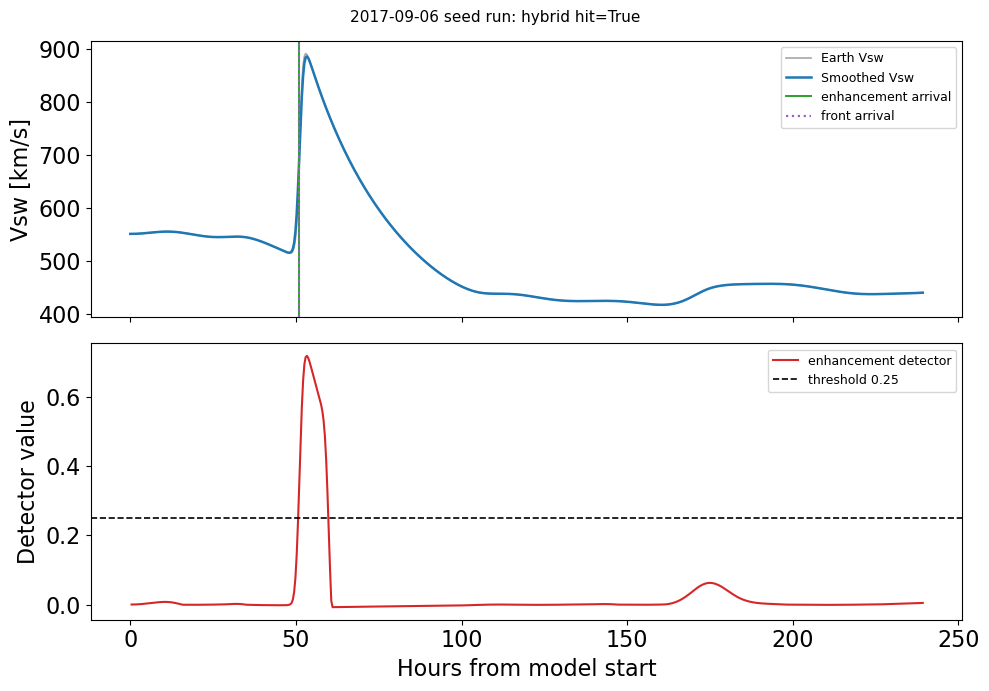

In [31]:
# 2c. Front + hybrid combine (front_arrival_metrics) and the diagnostic plot.
if huxt_ran:
    stats = cme.compute_arrival_at_body("EARTH")
    front_hit = bool(stats.get("hit", False))
    if front_hit:
        start = Time(huxt_time[0])
        front_arrival_hr = float(((stats["t_arrive"] - start).to("hour")).value)
    else:
        front_arrival_hr = np.nan

    # hybrid (script default): front crossing AND enhancement trigger.
    hybrid_hit = bool(front_hit and enh_hit)
    print(f"front_hit={front_hit}, front_arrival_hr={front_arrival_hr:.2f}" if front_hit
          else "front_hit=False")
    print("hybrid hit (front AND enhancement):", hybrid_hit)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(hours, speed, color="0.65", lw=1.2, label="Earth Vsw")
    axes[0].plot(hours, smooth, color="tab:blue", lw=1.8, label="Smoothed Vsw")
    if enh_hit:
        axes[0].axvline(enh_arrival_hr, color="tab:green", lw=1.4, label="enhancement arrival")
    if front_hit:
        axes[0].axvline(front_arrival_hr, color="tab:purple", ls=":", lw=1.6, label="front arrival")
    axes[0].set_ylabel("Vsw [km/s]")
    axes[0].legend(loc="best", fontsize=9)

    axes[1].plot(hours, enhancement, color="tab:red", lw=1.5, label="enhancement detector")
    axes[1].axhline(threshold, color="k", ls="--", lw=1.2, label=f"threshold {threshold:g}")
    axes[1].set_xlabel("Hours from model start")
    axes[1].set_ylabel("Detector value")
    axes[1].legend(loc="best", fontsize=9)
    fig.suptitle(f"{event} seed run: hybrid hit={hybrid_hit}", fontsize=11)
    fig.tight_layout()
else:
    print("No live HUXt series available; skipping the detector plot.")

### Building the training set

For every design row, `run_design()` runs the same simulation, calls `detect_arrival()` with the chosen `--detector-method`, and writes one scalar row to `results.csv`. The columns are exactly what Task 3 trains on: `hit` (the classifier target), `arrival_time_hr` (the regressor target, only meaningful when `hit`), and the raw detector diagnostics (`max_speed_*`, `front_*`) that explain *why* each row was called a hit or miss.

**Self-contained run.** If `results.csv` does not exist yet, the cell below **generates the batch inline** - it reuses the script's `make_design()` + `run_design()` to evaluate HUXt at ~200 samples (tens of minutes) and save `results.csv`. That keeps this notebook runnable on its own (lower `N_BATCH` for a quick look). It needs the event's boundary from notebook 02 (or `generate_huxt_input.py`).

> **What to look for:** the `hit` counts show how balanced the training set is - an arrival GP trained on very few hits (the script warns under ~30) should be trusted less.

In [32]:
import gp_huxt_surrogate as gp

results_file = outdir / "results.csv"
boundary_file = DATA_ROOT / event / f"v_boundary_{event}.npz"
if not results_file.exists():
    if not boundary_file.exists():
        raise FileNotFoundError(
            f"No {results_file} and no boundary {boundary_file}.\n"
            f"Run notebook 02 first (it downloads GONG, runs WSA+, and writes the boundary),\n"
            f"or: python scripts/generate_huxt_input.py --event {event}. Then re-run this cell."
        )
    # Self-contained path: build a small HUXt batch inline so the notebook can train a GP
    # without a separate gp_huxt_surrogate.py run. Reuses the script's design + run steps.
    N_BATCH = 200   # runs HUXt N_BATCH times (~tens of minutes); lower it for a quick look
    print(f"No results.csv yet - generating a {N_BATCH}-sample HUXt batch inline (~minutes)...")
    gp.make_design(event, DATA_ROOT, GP_ROOT, n=N_BATCH, seed=42, force=True,
                   span_inject_hour=DEFAULT_SPAN["inject_hour"],
                   span_longitude=DEFAULT_SPAN["longitude"],
                   span_latitude=DEFAULT_SPAN["latitude"],
                   span_width=DEFAULT_SPAN["width"],
                   span_speed_fraction=DEFAULT_SPAN["speed_fraction"])
    gp.run_design(event, DATA_ROOT, GP_ROOT, limit=N_BATCH, detector_threshold=0.25,
                  detector_lag=2, smooth_window=5, detector_method="hybrid",
                  baseline_window=24, rerun_completed=False)
    print(f"Wrote {results_file} (re-runs reuse it). For a sharper GP, run a larger batch:")
    print(f"  python scripts/gp_huxt_surrogate.py --event {event} design --n 300 / run / fit")

results = pd.read_csv(results_file)
detector_cols = [
    "sample_id", "hit", "arrival_time_hr", "max_speed_jump",
    "max_speed_enhancement", "max_detector_value", "front_hit", "front_arrival_time_hr",
]
print("status counts:")
print(results["status"].value_counts(dropna=False))
print("\nhit counts:")
print(results["hit"].value_counts(dropna=False))
display(results[detector_cols].head(10))

status counts:
status
completed    200
Name: count, dtype: int64

hit counts:
hit
True     155
False     45
Name: count, dtype: int64


,sample_id,hit,arrival_time_hr,max_speed_jump,max_speed_enhancement,max_detector_value,front_hit,front_arrival_time_hr
0,0,True,50.895755,0.184386,0.719000,0.719000,True,50.895755
1,1,True,49.402554,0.282044,1.010369,1.010369,True,49.402554
2,2,True,48.993450,0.397195,1.365404,1.365404,True,48.993450
3,3,False,NaN,0.005900,0.062635,0.062635,True,174.698000
4,4,True,53.959614,0.137508,0.585741,0.585741,True,53.959614
5,5,True,46.405754,0.297297,1.027075,1.027075,True,46.405754
6,6,True,52.091691,0.141399,0.621983,0.621983,True,52.091691
7,7,True,53.928302,0.160477,0.661184,0.661184,True,53.928302
8,8,True,47.305566,0.390120,1.292715,1.292715,True,47.305566
9,9,True,53.393582,0.180307,0.713548,0.713548,True,53.393582


## Task 3: The `fit` Step - training both GPs from scratch

*Mirrors `train_models()`, `predict_hit_probability()`, and `predict_arrival()`.*

`fit` trains two models on the completed `results.csv` rows:

- **`gp_hit`** - a `GaussianProcessClassifier` for `P(hit)` over **all** completed rows.
- **`gp_arrival`** - a `GaussianProcessRegressor` for `arrival_time_hr`, trained on **hit rows only** (a miss has no arrival time).

**A few modeling choices worth understanding:**

- **The kernel** (`ConstantKernel * Matern(nu=2.5)`): the Matern kernel sets how smoothly the prediction varies; one **length scale per parameter** lets the GP learn that, say, speed matters over a different scale than width. `nu=2.5` is a common moderately-smooth choice.
- **Standardizing** the inputs (and the arrival target) puts every parameter on a comparable scale, so those length scales are interpretable and the optimizer is well-conditioned.
- **`WhiteKernel`** on the regressor adds a learned noise floor that absorbs the run-to-run jitter in the *detected* arrival time (the detector is not perfectly smooth).
- **Holdout MAE (Mean Absolute Error)**: when there are enough hits, a held-out split estimates the typical arrival-time error in hours - the headline accuracy number.

> **What to look for:** the learned length scales (printed in the kernel) hint at which parameters arrival time is most sensitive to; the holdout MAE tells you whether to trust the surrogate to the hour or only the half-day.

In [33]:
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split

def parse_bool(value):
    """Parse a boolean value from a string or a boolean type."""
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {"1", "true", "yes", "y"}

completed = results.loc[results["status"] == "completed"].copy()
completed["hit"] = completed["hit"].map(parse_bool)
x = completed[PARAM_NAMES].to_numpy(float)
hit = completed["hit"].astype(int).to_numpy()

x_scaler = StandardScaler().fit(x)
x_scaled = x_scaler.transform(x)
print(f"completed rows: {len(completed)}, hit rows: {int(hit.sum())}")

completed rows: 200, hit rows: 155


In [34]:
# 3a. Hit classifier over all completed rows.
# - ConstantKernel amplitude starts at 1.0 with wide bounds so the GP can scale signal variance freely.
# - Matern(nu=2.5) is a robust default for moderately smooth, non-linear decision boundaries.
# - One length scale per parameter (ARD) lets the model infer which inputs vary faster/slower.
# - Since inputs are standardized (x_scaled), an initial length_scale=1 is a sensible neutral start.
# - Broad length_scale bounds avoid over-constraining the optimizer.
hit_kernel = ConstantKernel(
    constant_value=1.0, constant_value_bounds=(1e-3, 1e5)
) * Matern(
    length_scale=np.ones(len(PARAM_NAMES)),
    length_scale_bounds=(1e-2, 1e5),
    nu=2.5,
)
hit_model = GaussianProcessClassifier(kernel=hit_kernel, random_state=42, max_iter_predict=100)
hit_model.fit(x_scaled, hit)
print("training accuracy:", accuracy_score(hit, hit_model.predict(x_scaled)))
print("learned hit kernel:", hit_model.kernel_)

training accuracy: 0.935
learned hit kernel: 18.2**2 * Matern(length_scale=[1e+05, 7.73, 2.35e+04, 9, 1e+05], nu=2.5)


/Users/u0167590/miniforge3/envs/conecast/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/u0167590/miniforge3/envs/conecast/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [35]:
# 3b. Arrival regressor on hit rows only, with a holdout MAE when there are enough cases.
hit_rows = completed.loc[completed["hit"] & np.isfinite(completed["arrival_time_hr"])].copy()
x_hit = x_scaler.transform(hit_rows[PARAM_NAMES].to_numpy(float))
y_hit = hit_rows[["arrival_time_hr"]].to_numpy(float)
y_scaler = StandardScaler().fit(y_hit)
y_scaled = y_scaler.transform(y_hit).ravel()

arrival_kernel = ConstantKernel(1.0, (1e-3, 1e5)) * Matern(
    length_scale=np.ones(len(PARAM_NAMES)), length_scale_bounds=(1e-2, 1e4), nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
arrival_model = GaussianProcessRegressor(
    kernel=arrival_kernel, normalize_y=False, n_restarts_optimizer=3, random_state=42)

if len(hit_rows) >= 10:
    xtr, xte, ytr, yte = train_test_split(x_hit, y_scaled, test_size=0.2, random_state=42)
    arrival_model.fit(xtr, ytr)
    pred_hr = y_scaler.inverse_transform(arrival_model.predict(xte).reshape(-1, 1)).ravel()
    true_hr = y_scaler.inverse_transform(yte.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(true_hr, pred_hr)
    # Is that MAE large? Judge it against (a) the spread of arrival times the GP has to
    # explain and (b) a no-skill baseline that always predicts the mean arrival time.
    baseline_mae = mean_absolute_error(true_hr, np.full_like(true_hr, true_hr.mean()))
    skill = 1.0 - mae / baseline_mae
    print(f"holdout arrival MAE [hr]: {mae:.2f}")
    print(f"  arrival spread on holdout: std={true_hr.std():.2f} hr, "
          f"range={true_hr.max() - true_hr.min():.1f} hr")
    print(f"  no-skill baseline MAE (predict the mean): {baseline_mae:.2f} hr"
          f"  ->  skill = 1 - MAE/baseline = {skill:.2f}  (1=perfect, 0=no better than the mean)")

arrival_model.fit(x_hit, y_scaled)   # final fit on all hit rows
print("learned arrival kernel:", arrival_model.kernel_)

holdout arrival MAE [hr]: 0.26
  arrival spread on holdout: std=4.31 hr, range=16.1 hr
  no-skill baseline MAE (predict the mean): 3.58 hr  ->  skill = 1 - MAE/baseline = 0.93  (1=perfect, 0=no better than the mean)
learned arrival kernel: 33.8**2 * Matern(length_scale=[529, 8.74, 15.6, 10.6, 42.2], nu=2.5) + WhiteKernel(noise_level=0.00207)


In [36]:
# 3c. Prediction helpers (mirror predict_hit_probability / predict_arrival) used by Task 4.
def predict_hit_probability(theta):
    return hit_model.predict_proba(x_scaler.transform(np.atleast_2d(theta)))[:, 1]

def predict_arrival(theta):
    mean_s, std_s = arrival_model.predict(x_scaler.transform(np.atleast_2d(theta)), return_std=True)
    mean = y_scaler.inverse_transform(mean_s.reshape(-1, 1)).ravel()
    std = std_s * float(y_scaler.scale_[0])
    return mean, std

mean_hr, std_hr = predict_arrival(theta0)
print("seed P(hit):", float(predict_hit_probability(theta0)[0]))
print("seed arrival mean [hr]:", float(mean_hr[0]), "std [hr]:", float(std_hr[0]))

# These freshly trained models match the committed gp_hit.joblib / gp_arrival.joblib bundles.

seed P(hit): 0.9742462258724345
seed arrival mean [hr]: 50.87875613199567 std [hr]: 0.234953476115126


## Task 4: The `analyze` Step

*Mirrors `analyze_event()`.* With a trained surrogate in hand we can answer the science questions - how arrival time varies across the parameter space (4a), which parameters drive it locally (4b) and globally (4c), what arrival time to expect given observational uncertainty (4d), and where the next HUXt run would be most informative (4e).

### Task 4a: Pairwise slices

*Mirrors `pair_grid()`, `make_hit_slice()`, `make_arrival_slice()`.*

You cannot draw a 5-D function, so we take 2-D **slices**: pick two parameters, sweep them across the bounds box on a grid, and hold the other three fixed at the seed. For each grid we render three fields - `P(hit)`, the arrival-time **mean**, and the arrival-time **std** (the GP's own uncertainty) - with the `P(hit)=0.5` decision contour drawn in white. Read the std panel as "where would I *not* trust the mean".

Arrival time is only meaningful where the CME actually hits. Where `P(hit)` collapses to ~0 the arrival GP extrapolates to unphysical values that dominate the color scale. Rather than punch holes in the map, every cell stays colored and we only adjust the **color limits**: they are computed from the hit region (`P(hit) >= 0.5`) alone, floored at 48 hr and capped at the **90th percentile** of the in-hit arrival times. Cells outside that range - including the no-hit band - saturate to the end colors (`extend="both"`), so the dense bulk keeps its contrast while the map stays continuous.

> **What to look for:** the white contour separates "arrives" from "misses" (the blank area in the arrival panels is the miss region); gradients in the mean panel show which direction speeds up or delays arrival; bright bands in the std panel flag thinly-sampled regions where another HUXt run would help (revisited in 4e).

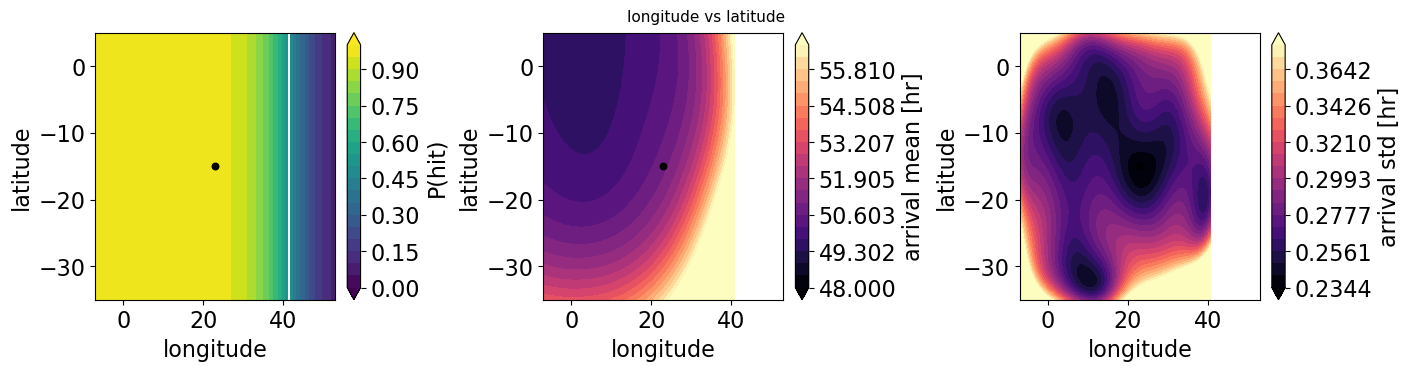

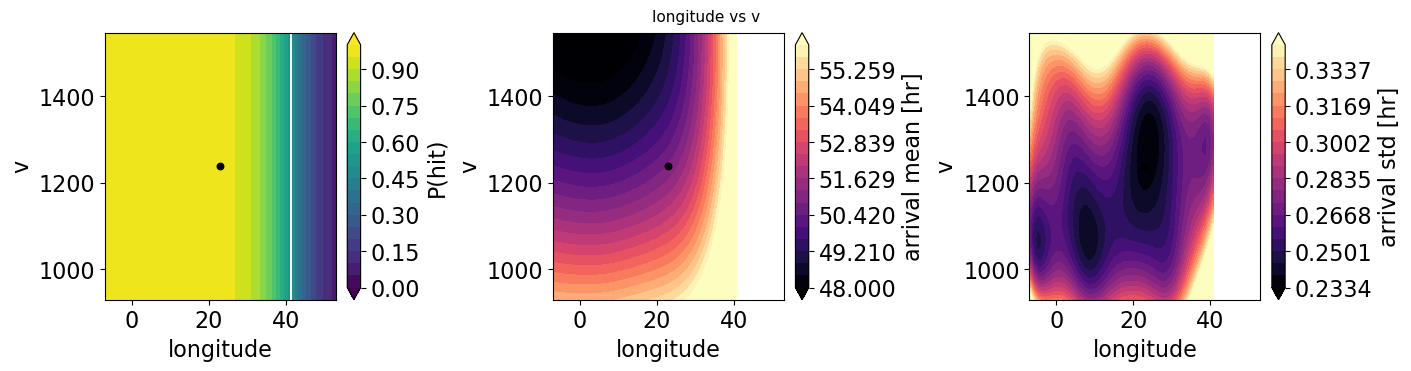

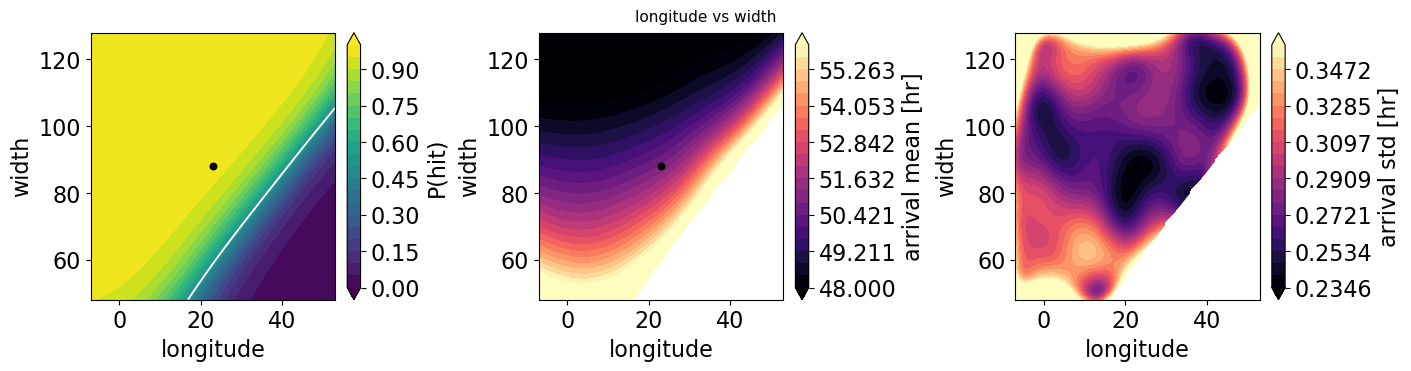

In [37]:
ARRIVAL_FLOOR_HR = 48.0   # color floor: arrival times below this are not physical
HIT_FLOOR = 0.5           # set color limits from the hit region only
ARRIVAL_CAP_PCT = 90.0    # cap the upper color limit so the grazing-CME tail doesn't dominate

def pair_grid(x_idx, y_idx, grid_size=60):
    """Create a grid of theta vectors varying the two parameters at x_idx and y_idx, 
    with the rest fixed at theta0."""
    gx = np.linspace(low[x_idx], high[x_idx], grid_size)
    gy = np.linspace(low[y_idx], high[y_idx], grid_size)
    xx, yy = np.meshgrid(gx, gy)
    theta = np.tile(theta0, (grid_size * grid_size, 1))
    theta[:, x_idx] = xx.ravel()
    theta[:, y_idx] = yy.ravel()
    return xx, yy, theta

def color_limits(field, hit, vmin=None):
    """Compute color limits for a field based on the hit region."""
    # Limits from the hit region only: lo floored (if given), hi at the 90th percentile.
    vals = field[hit & np.isfinite(field)]
    if vals.size == 0:
        return None
    lo = float(vmin) if vmin is not None else float(vals.min())
    return lo, float(np.percentile(vals, ARRIVAL_CAP_PCT))

pairs = [("longitude", "latitude"), ("longitude", "v"), ("longitude", "width")]
for xn, yn in pairs:
    xi, yi = PARAM_NAMES.index(xn), PARAM_NAMES.index(yn)
    xx, yy, theta = pair_grid(xi, yi)
    gs = xx.shape[0]
    prob = predict_hit_probability(theta).reshape(gs, gs)
    mean, std = predict_arrival(theta)
    mean = mean.reshape(gs, gs)
    std = std.reshape(gs, gs)

    # Arrival time is only meaningful where the CME actually hits. The regressor is trained
    # on hit rows only, so in the miss region it just extrapolates a (physically meaningless)
    # number - blank those cells out and use the hit region to set robust color limits.
    hit = prob >= HIT_FLOOR
    mean = np.where(hit, mean, np.nan)
    std = np.where(hit, std, np.nan)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
    panels = [
        (axes[0], prob, "viridis", "P(hit)", (0.0, 1.0)),
        (axes[1], mean, "magma", "arrival mean [hr]", color_limits(mean, hit, vmin=ARRIVAL_FLOOR_HR)),
        (axes[2], std, "magma", "arrival std [hr]", color_limits(std, hit)),
    ]
    for ax, field, cmap, label, limits in panels:
        if limits is None or np.isclose(limits[0], limits[1]):
            c = ax.contourf(xx, yy, field, levels=21, cmap=cmap)
        else:
            levels = np.linspace(limits[0], limits[1], 21)
            c = ax.contourf(xx, yy, field, levels=levels, cmap=cmap, extend="both")
        fig.colorbar(c, ax=ax, label=label)
        if np.nanmin(prob) <= 0.5 <= np.nanmax(prob):
            ax.contour(xx, yy, prob, levels=[0.5], colors="white", linewidths=1.4)
        ax.scatter(theta0[xi], theta0[yi], color="black", s=22, zorder=3)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
    fig.suptitle(f"{xn} vs {yn}", fontsize=11)
    plt.show()

### Task 4b: Local sensitivity (finite-difference gradients)

*Mirrors `finite_difference_gradients()`.* This answers "right at the best-guess CME, how does arrival time respond to a small change in each parameter?" We nudge each parameter by 1% of its range around the seed and take a central difference of the GP-predicted arrival time, giving **d(arrival)/d(parameter)** in hours per unit (hours per km/s, hours per degree, ...).

The sign gives direction (a faster CME arrives earlier, so a negative slope on `v`); the magnitude gives leverage. Because the units differ per parameter, compare with care - 4c gives a unit-free global view.

> **What to look for:** `v` (speed) usually has the strongest, negative slope. This is a **local** measure, valid near the seed only; far away the surface bends (see the slices in 4a).

baseline arrival [hr]: 50.87875613199567


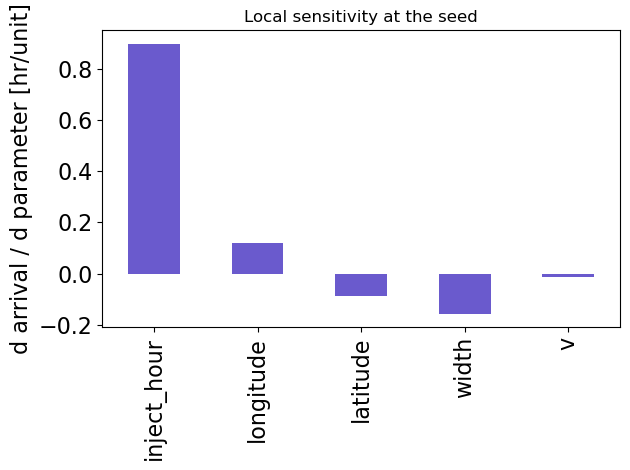

In [38]:
base_mean, _ = predict_arrival(theta0)
gradients = {}
for idx, name in enumerate(PARAM_NAMES):
    step = max((high[idx] - low[idx]) * 0.01, 1e-6)
    plus, minus = theta0.copy(), theta0.copy() # start at the seed
    plus[idx] = min(high[idx], plus[idx] + step) # step up, clipped to the box
    minus[idx] = max(low[idx], minus[idx] - step) # step down, clipped to the box
    if plus[idx] == minus[idx]:
        gradients[name] = np.nan
        continue
    y_plus, _ = predict_arrival(plus)
    y_minus, _ = predict_arrival(minus)
    gradients[name] = float((y_plus[0] - y_minus[0]) / (plus[idx] - minus[idx]))

print("baseline arrival [hr]:", float(base_mean[0]))
pd.Series(gradients).plot(kind="bar", color="slateblue")
plt.ylabel("d arrival / d parameter [hr/unit]")
plt.title("Local sensitivity at the seed")
plt.tight_layout()

### Task 4c: Permutation importance

*Mirrors `permutation_importance()`.* Where 4b is a *local* derivative at the seed, this is a *global* importance over the whole plausible region. We draw a cloud of posterior-like samples (Task 4d's distribution), then shuffle one parameter's column at a time and measure how much the predicted arrival time changes (mean squared deviation, in hr^2). If scrambling a parameter barely changes the prediction the surrogate does not rely on it; if it changes a lot, that parameter dominates.

> **What to look for:** the ranking should broadly agree with 4b's magnitudes (speed near the top) but can differ where the response is non-linear across the region. Unlike 4b these values are directionless and comparable across parameters.

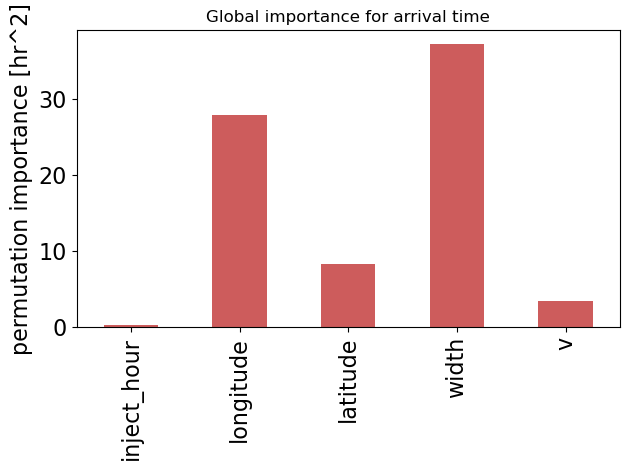

In [43]:
def truncated_normal_samples(theta0, sigma, low, high, n, seed):
    rng = np.random.default_rng(seed)
    samples = rng.normal(theta0, sigma, size=(n, len(theta0)))
    for _ in range(20):
        bad = (samples < low) | (samples > high)
        if not bad.any():
            break
        samples = np.where(bad, rng.normal(theta0, sigma, size=samples.shape), samples)
    return np.clip(samples, low, high)

sigma = DEFAULT_OBS_SIGMA.copy()
sigma[4] = 0.10 * theta0[4]
samples = truncated_normal_samples(theta0, sigma, low, high, 3000, seed=43)

baseline, _ = predict_arrival(samples)
rng = np.random.default_rng(45)
importance = {}
for idx, name in enumerate(PARAM_NAMES):
    permuted = samples.copy()
    permuted[:, idx] = rng.permutation(permuted[:, idx])
    pred, _ = predict_arrival(permuted)
    importance[name] = float(np.mean((baseline - pred) ** 2))

pd.Series(importance).plot(kind="bar", color="indianred")
plt.ylabel("permutation importance [hr^2]")
plt.title("Global importance for arrival time")
plt.tight_layout()

In [45]:
samples.shape

(3000, 5)

### Task 4d: Posterior arrival time

*Mirrors the posterior block of `analyze_event()` plus `truncated_normal_samples()`.* This turns "we don't know the CME parameters exactly" into "here is the spread of arrival times to expect". We treat the seed as a **noisy observation**, draw parameter vectors around it (a truncated normal with widths `DEFAULT_OBS_SIGMA`), and push each through the arrival GP.

The result folds together **two** sources of uncertainty: the *input* uncertainty (we are unsure of the parameters) and the *surrogate* uncertainty (the GP's own predictive std). Adding a normal draw of width `post_std` to each predicted mean produces the posterior-predictive distribution.

> **What to look for:** the histogram's spread is your honest arrival-time error bar; the printed p05/median/p95 form a 90% credible interval. A wide distribution means uncertain inputs, a thinly-trained GP, or both.

posterior arrival [hr]  p05=47.1  median=51.8  p95=64.2
mean P(hit) over posterior: 0.8715542112999382


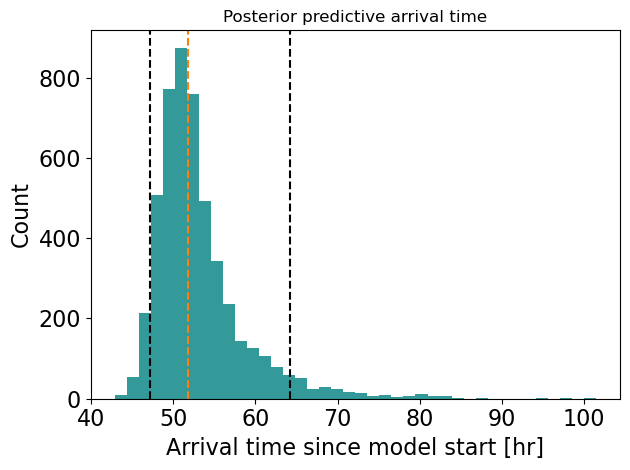

In [40]:
post_theta = truncated_normal_samples(theta0, sigma, low, high, 5000, seed=42)
post_mean, post_std = predict_arrival(post_theta)
draw = np.random.default_rng(43).normal(post_mean, post_std)
draw = draw[np.isfinite(draw)]

p05, med, p95 = np.percentile(draw, [5, 50, 95])
print(f"posterior arrival [hr]  p05={p05:.1f}  median={med:.1f}  p95={p95:.1f}")
print("mean P(hit) over posterior:", float(np.mean(predict_hit_probability(post_theta))))

plt.hist(draw, bins=40, color="teal", alpha=0.8)
for q, c in [(p05, "k"), (med, "tab:orange"), (p95, "k")]:
    plt.axvline(q, color=c, ls="--")
plt.xlabel("Arrival time since model start [hr]")
plt.ylabel("Count")
plt.title("Posterior predictive arrival time")
plt.tight_layout()

### Task 4e: Next-run selection

*Mirrors `select_next_runs()`.* HUXt runs are the expensive resource, so where should the next batch go? This is **active learning**: pick parameter vectors that will teach the surrogate the most. The script scores random candidates with three factors, then greedily spreads the picks out in parameter space:

```text
score = arrival_std * (0.25 + boundary_weight) * (0.25 + likelihood_weight)
```

- `arrival_std` favors candidates where the arrival GP is **uncertain** (most to learn).
- `boundary_weight = 1 - |P(hit) - 0.5| * 2` favors the **hit/miss boundary** (where classification is hardest).
- `likelihood_weight = exp(-0.5 * z^2 / ndim)` keeps candidates **near the seed** (where it matters for this event).

After scoring, a distance penalty in scaled space spreads the batch out so we do not propose near-duplicate runs.

> **What to look for:** the selected points should cluster near the `P(hit)=0.5` boundary and in the high-std bands from 4a, while staying in the seed's neighborhood - exactly the places another HUXt run sharpens the surrogate.

,inject_hour,longitude,latitude,width,v,score,p_hit,arrival_std_hr
0,4.007730,26.526057,-33.488565,63.331993,1224.331572,1.049414,0.460586,1.168318
1,2.969681,26.766030,-34.380083,65.938879,1278.393054,0.948806,0.530418,1.170344
2,3.626466,38.266324,4.289088,81.724833,950.821316,0.541683,0.453837,0.832219
3,3.601424,20.381908,-29.903430,53.294887,1536.935900,0.761048,0.473042,1.251162
4,3.247531,17.276016,-30.897675,49.787402,931.035185,0.649576,0.528134,1.224194
5,4.581544,16.538587,-32.582245,49.906273,1430.268724,0.749934,0.565718,1.441228
6,4.044027,49.610816,3.513202,49.190548,1493.379883,0.454964,0.003415,4.892649
7,3.480465,51.764918,-13.411441,50.110896,1099.186081,0.598722,0.002805,5.220385
8,3.381500,21.975314,-33.470406,53.029924,1289.022537,1.022004,0.388672,1.560094
9,4.046625,41.160825,-34.888915,84.642067,1406.776600,0.742699,0.399227,1.119131


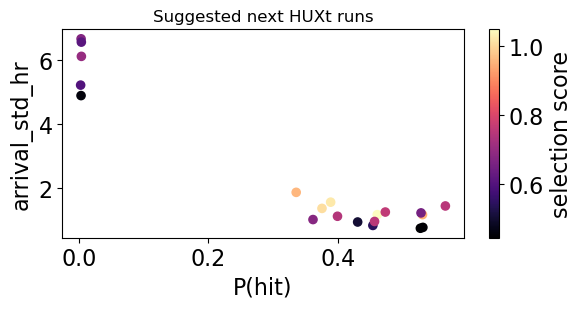

In [41]:
n_candidates, batch_size = 4000, 20
rng = np.random.default_rng(44)
candidates = low + rng.random((n_candidates, len(theta0))) * (high - low)

_, arrival_std = predict_arrival(candidates)
p_hit = predict_hit_probability(candidates)
z2 = np.sum(((candidates - theta0) / sigma) ** 2, axis=1)
likelihood_weight = np.exp(-0.5 * z2 / len(theta0))
boundary_weight = 1.0 - np.abs(p_hit - 0.5) * 2.0
score = arrival_std * (0.25 + boundary_weight) * (0.25 + likelihood_weight)

# Greedy space-filling selection in scaled coordinates.
scaled = x_scaler.transform(candidates)
selected = [int(np.argmax(score))]
available = np.delete(np.arange(n_candidates), selected[0])
while len(selected) < batch_size and available.size:
    dist = np.min(np.linalg.norm(
        scaled[available, None, :] - scaled[np.array(selected)][None, :, :], axis=2), axis=1)
    nxt = int(available[np.argmax(score[available] * (1.0 + dist))])
    selected.append(nxt)
    available = available[available != nxt]

next_runs = pd.DataFrame(candidates[selected], columns=PARAM_NAMES)
next_runs["score"] = score[selected]
next_runs["p_hit"] = p_hit[selected]
next_runs["arrival_std_hr"] = arrival_std[selected]
display(next_runs.head(10))

plt.figure(figsize=(6, 3.2))
plt.scatter(next_runs["p_hit"], next_runs["arrival_std_hr"], c=next_runs["score"], cmap="magma", s=35)
plt.colorbar(label="selection score")
plt.xlabel("P(hit)")
plt.ylabel("arrival_std_hr")
plt.title("Suggested next HUXt runs")
plt.tight_layout()

## Task 5: Compare against the committed CLI figures

*Mirrors the figure-writing in `analyze_event()`.* Every analysis above was reimplemented inline; the production script saves its own versions under `figures/`. Displaying them next to your reconstructions is the final check that you understood each operation - if a panel disagrees, the difference is a clue. For example, the committed `arrival_mean_*.png` uses the 24-96 hr window set in `gp_huxt_surrogate.py`, while Task 4a uses the floor-48 / p90-cap recipe, so their color scales differ by design.

> **What to look for:** shapes and structures should match; exact color scales may differ where the script and notebook use different limit conventions.

In [42]:
figure_names = [
    "posterior_arrival_time.png",
    "permutation_importance.png",
    "local_sensitivity.png",
    "hit_probability_longitude_v.png",
    "arrival_mean_longitude_v.png",
    "arrival_std_longitude_v.png",
]

for name in figure_names:
    path = outdir / "figures" / name
    print(name, "exists:", path.exists())
    if path.exists():
        display(Image(filename=str(path), width=760))

posterior_arrival_time.png exists: False
permutation_importance.png exists: False
local_sensitivity.png exists: False
hit_probability_longitude_v.png exists: False
arrival_mean_longitude_v.png exists: False
arrival_std_longitude_v.png exists: False
